**Simple Tree Data Structure**

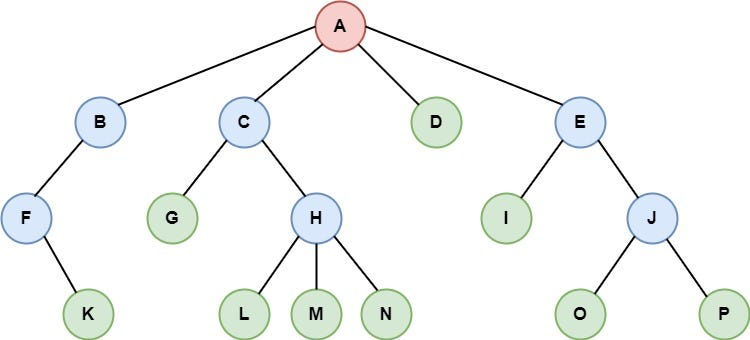

**Binary Tree**

Search = O(n)

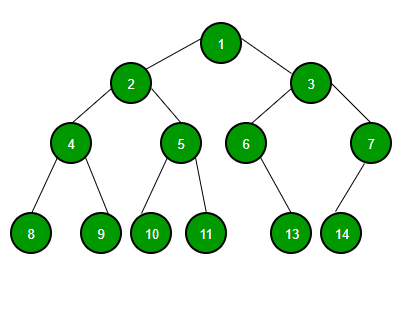

Questions:

1. Children of 2?
2. No. of leaves?
3. Parent of 6?
4. Level of 7?
5. Subtree of 2 and 6?
6. Ancestor of 8?


**Binary Search Tree**

Search = Average O(log H) where H is height of the tree. Worst is O(n) if Tree is skewed.

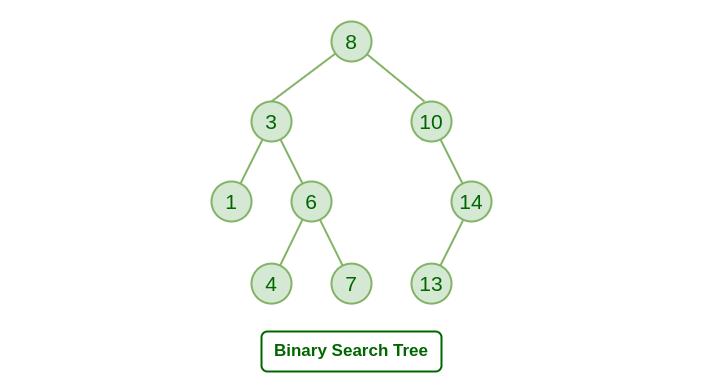

**Rules of Binary Search Tree**:


1.   All Left nodes will be < Root Node
2.   All Right nodes will be > Root Node

In default BST we consider all elements are unique.



In [16]:
class Node:
  def __init__(self, val):
    self.val = val
    self.left = None
    self.right = None

In [17]:
# Insert into BST
def insert(root, val):
    if root is None:
        return Node(val)

    if val < root.val:
        root.left = insert(root.left, val)
    else:
        root.right = insert(root.right, val)

    return root

In [18]:
# Search into BST - Average complexity O(log n), worst O(n) for Skewwed BST
def search(root, val):
    if root is None or root.val == val:
        return root

    if val < root.val:
        return search(root.left, val)
    else:
        return search(root.right, val)

In [19]:
# Inorder Traversal (Sorted Output)
def inorder(root):
    if root:
        inorder(root.left)
        print(root.val, end=" ")
        inorder(root.right)

In [20]:
# Delete from BST (All 3 Cases)
def delete(root, val):
    if not root:
        return root

    if val < root.val:
        root.left = delete(root.left, val)

    elif val > root.val:
        root.right = delete(root.right, val)

    else:
        # Case 1: 0 child
        if not root.left and not root.right:
          return None

        # Case 2: 1 child
        if not root.left:
            return root.right
        elif not root.right:
            return root.left

        # Case 3: 2 children
        nextSuccessor = inorderSuccessor(root.right)
        root.val = nextSuccessor.val
        root.right = delete(root.right, nextSuccessor.val)

    return root


def inorderSuccessor(node):
    current = node
    while current.left:
        current = current.left
    return current

In [21]:
root = None
values = [8, 3, 10, 1, 6, 14, 4, 7]

for v in values:
    root = insert(root, v)

print("Inorder traversal:")
inorder(root)

print("\nSearch 6:")
print("Found" if search(root, 6) else "Not Found")

print("\nDelete 3:")
root = delete(root, 3)
inorder(root)


Inorder traversal:
1 3 4 6 7 8 10 14 
Search 6:
Found

Delete 3:
1 4 6 7 8 10 14 